In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/FIRMS/fire_archive_SV-C2_806010.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (1739550, 15)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,11.60804,79.38103,330.42,0.34,0.56,2023-09-15,726,SNPP,SNPP,n,2,291.44,1.57,D,0
1,9.83476,79.06087,367.00,0.38,0.59,2023-09-15,726,SNPP,SNPP,h,2,291.72,10.62,D,0
2,9.65347,78.72186,338.66,0.40,0.60,2023-09-15,726,SNPP,SNPP,n,2,292.06,4.74,D,0
3,9.83540,79.06435,345.56,0.38,0.59,2023-09-15,726,SNPP,SNPP,n,2,291.12,11.50,D,0
4,12.68536,79.35842,343.66,0.32,0.55,2023-09-15,726,SNPP,SNPP,n,2,290.17,3.61,D,0


In [2]:
df["acq_datetime"] = pd.to_datetime(
    df["acq_date"].astype(str) + " " +
    df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    errors="coerce"
)

print(df["acq_datetime"].isna().sum(), "invalid timestamps")

0 invalid timestamps


In [3]:
df["hour"] = df["acq_datetime"].dt.hour
df["day_of_week"] = df["acq_datetime"].dt.dayofweek
df["month"] = df["acq_datetime"].dt.month
df["day_of_year"] = df["acq_datetime"].dt.dayofyear

df[[
    "acq_datetime",
    "hour",
    "day_of_week",
    "month",
    "day_of_year"
]].head()

,acq_datetime,hour,day_of_week,month,day_of_year
0,2023-09-15 07:26:00,7,4,9,258
1,2023-09-15 07:26:00,7,4,9,258
2,2023-09-15 07:26:00,7,4,9,258
3,2023-09-15 07:26:00,7,4,9,258
4,2023-09-15 07:26:00,7,4,9,258


In [4]:
df["acq_datetime"] = pd.to_datetime(
    df["acq_date"].astype(str) + " " +
    df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    errors="coerce"
)

df = df.dropna(subset=["latitude", "longitude", "acq_datetime"])

df = df.sort_values("acq_datetime").reset_index(drop=True)

print("Clean shape:", df.shape)

Clean shape: (1739550, 20)


In [5]:
GRID_SIZE = 0.01  # approximately 1 km at the equator

df["lat_grid"] = np.floor(df["latitude"] / GRID_SIZE) * GRID_SIZE
df["lon_grid"] = np.floor(df["longitude"] / GRID_SIZE) * GRID_SIZE

df["grid_id"] = (
    df["lat_grid"].round(2).astype(str)
    + "_"
    + df["lon_grid"].round(2).astype(str)
)

print("Unique spatial cells:", df["grid_id"].nunique())

Unique spatial cells: 644699


In [6]:
cell_stats = (
    df.groupby("grid_id")
      .agg(
          observation_count=("grid_id", "size"),
          mean_frp=("frp", "mean"),
          max_frp=("frp", "max"),
          mean_brightness=("brightness", "mean"),
          max_brightness=("brightness", "max"),
          first_seen=("acq_datetime", "min"),
          last_seen=("acq_datetime", "max")
      )
      .reset_index()
)

cell_stats["persistence_days"] = (
    cell_stats["last_seen"] - cell_stats["first_seen"]
).dt.total_seconds() / (24 * 3600)

display(cell_stats.sort_values(
    "observation_count", ascending=False
).head(20))

,grid_id,observation_count,mean_frp,max_frp,mean_brightness,max_brightness,first_seen,last_seen,persistence_days
300469,22.04_83.73,3217,5.843388,52.27,330.450933,367.00,2023-09-16 19:39:00,2026-06-27 20:57:00,1015.054167
252598,21.1_72.64,3139,6.573386,55.27,330.138152,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972
241357,20.96_85.17,3060,3.072908,14.39,319.125020,354.22,2023-09-15 07:28:00,2026-06-30 20:01:00,1019.522917
252597,21.1_72.63,2823,5.158569,41.76,325.864917,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972
392752,23.68_86.39,2785,3.035285,12.99,318.745311,354.23,2023-09-16 19:38:00,2026-06-30 20:00:00,1018.015278
398051,23.76_86.4,2630,2.954684,14.52,319.053658,351.15,2023-09-15 07:29:00,2026-06-30 20:00:00,1019.521528
234038,20.79_85.25,2441,3.959373,18.11,321.737923,367.00,2023-09-16 19:39:00,2026-06-30 20:01:00,1018.015278
398050,23.76_86.39,2024,2.679605,15.18,311.422268,367.00,2023-09-16 19:38:00,2026-06-30 20:00:00,1018.015278
362956,23.16_82.33,1997,3.212599,15.10,320.736560,367.00,2023-09-24 20:28:00,2026-06-28 20:38:00,1008.006944
398677,23.77_86.2,1946,2.586213,13.91,312.235735,367.00,2023-09-16 19:38:00,2026-06-26 19:35:00,1013.997917


In [7]:
cell_stats = (
    df.groupby("grid_id")
      .agg(
          observation_count=("grid_id", "size"),
          mean_frp=("frp", "mean"),
          max_frp=("frp", "max"),
          mean_brightness=("brightness", "mean"),
          max_brightness=("brightness", "max"),
          first_seen=("acq_datetime", "min"),
          last_seen=("acq_datetime", "max")
      )
      .reset_index()
)

cell_stats["persistence_days"] = (
    cell_stats["last_seen"] - cell_stats["first_seen"]
).dt.total_seconds() / (24 * 3600)

display(cell_stats.sort_values(
    "observation_count", ascending=False
).head(20))

,grid_id,observation_count,mean_frp,max_frp,mean_brightness,max_brightness,first_seen,last_seen,persistence_days
300469,22.04_83.73,3217,5.843388,52.27,330.450933,367.00,2023-09-16 19:39:00,2026-06-27 20:57:00,1015.054167
252598,21.1_72.64,3139,6.573386,55.27,330.138152,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972
241357,20.96_85.17,3060,3.072908,14.39,319.125020,354.22,2023-09-15 07:28:00,2026-06-30 20:01:00,1019.522917
252597,21.1_72.63,2823,5.158569,41.76,325.864917,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972
392752,23.68_86.39,2785,3.035285,12.99,318.745311,354.23,2023-09-16 19:38:00,2026-06-30 20:00:00,1018.015278
398051,23.76_86.4,2630,2.954684,14.52,319.053658,351.15,2023-09-15 07:29:00,2026-06-30 20:00:00,1019.521528
234038,20.79_85.25,2441,3.959373,18.11,321.737923,367.00,2023-09-16 19:39:00,2026-06-30 20:01:00,1018.015278
398050,23.76_86.39,2024,2.679605,15.18,311.422268,367.00,2023-09-16 19:38:00,2026-06-30 20:00:00,1018.015278
362956,23.16_82.33,1997,3.212599,15.10,320.736560,367.00,2023-09-24 20:28:00,2026-06-28 20:38:00,1008.006944
398677,23.77_86.2,1946,2.586213,13.91,312.235735,367.00,2023-09-16 19:38:00,2026-06-26 19:35:00,1013.997917


In [8]:
daily_activity = (
    df.groupby("grid_id")["acq_date"]
      .nunique()
      .reset_index(name="active_days")
)

cell_stats = cell_stats.merge(
    daily_activity,
    on="grid_id",
    how="left"
)

cell_stats["recurrence_ratio"] = (
    cell_stats["active_days"] /
    cell_stats["persistence_days"].clip(lower=1)
)

display(
    cell_stats.sort_values(
        "active_days", ascending=False
    ).head(20)
)

,grid_id,observation_count,mean_frp,max_frp,mean_brightness,max_brightness,first_seen,last_seen,persistence_days,active_days,recurrence_ratio
252598,21.1_72.64,3139,6.573386,55.27,330.138152,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972,796,0.786180
252597,21.1_72.63,2823,5.158569,41.76,325.864917,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972,786,0.776303
392752,23.68_86.39,2785,3.035285,12.99,318.745311,354.23,2023-09-16 19:38:00,2026-06-30 20:00:00,1018.015278,722,0.709223
300469,22.04_83.73,3217,5.843388,52.27,330.450933,367.00,2023-09-16 19:39:00,2026-06-27 20:57:00,1015.054167,717,0.706366
398051,23.76_86.4,2630,2.954684,14.52,319.053658,351.15,2023-09-15 07:29:00,2026-06-30 20:00:00,1019.521528,707,0.693463
234038,20.79_85.25,2441,3.959373,18.11,321.737923,367.00,2023-09-16 19:39:00,2026-06-30 20:01:00,1018.015278,691,0.678772
241357,20.96_85.17,3060,3.072908,14.39,319.125020,354.22,2023-09-15 07:28:00,2026-06-30 20:01:00,1019.522917,687,0.673845
397406,23.75_86.4,1594,3.098375,15.27,320.608959,367.00,2023-09-16 07:10:00,2026-06-30 20:00:00,1018.534722,680,0.667626
362957,23.16_82.34,1656,3.076413,15.14,321.583937,353.55,2023-09-23 20:47:00,2026-06-28 20:38:00,1008.993750,677,0.670966
398677,23.77_86.2,1946,2.586213,13.91,312.235735,367.00,2023-09-16 19:38:00,2026-06-26 19:35:00,1013.997917,652,0.642999


In [9]:
daynight_stats = (
    df.groupby("grid_id")["daynight"]
      .agg(
          day_observations=lambda x: (x == "D").sum(),
          night_observations=lambda x: (x == "N").sum()
      )
      .reset_index()
)

cell_stats = cell_stats.merge(
    daynight_stats,
    on="grid_id",
    how="left"
)

cell_stats["night_ratio"] = (
    cell_stats["night_observations"] /
    cell_stats["observation_count"].clip(lower=1)
)

display(cell_stats.head())

,grid_id,observation_count,mean_frp,max_frp,mean_brightness,max_brightness,first_seen,last_seen,persistence_days,active_days,recurrence_ratio,day_observations,night_observations,night_ratio
0,10.01_76.74,3,3.740,6.57,336.660,344.37,2024-03-18 07:57:00,2026-02-19 08:21:00,703.016667,3,0.004267,3,0,0.0
1,10.01_76.75,1,3.260,3.26,334.940,334.94,2026-02-19 08:21:00,2026-02-19 08:21:00,0.000000,1,1.000000,1,0,0.0
2,10.01_76.8,1,0.560,0.56,300.150,300.15,2025-02-28 20:26:00,2025-02-28 20:26:00,0.000000,1,1.000000,0,1,1.0
3,10.01_76.82,2,4.295,5.68,336.225,341.91,2024-04-01 08:35:00,2024-04-01 08:35:00,0.000000,1,1.000000,2,0,0.0
4,10.01_76.85,1,1.480,1.48,305.720,305.72,2024-03-02 20:32:00,2024-03-02 20:32:00,0.000000,1,1.000000,0,1,1.0


In [10]:
import os

OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = f"{OUTPUT_DIR}/firms_spatial_features.csv"

cell_stats.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Shape:", cell_stats.shape)
print("Columns:")
print(cell_stats.columns.tolist())

Saved: ../data/processed/firms_spatial_features.csv
Shape: (644699, 14)
Columns:
['grid_id', 'observation_count', 'mean_frp', 'max_frp', 'mean_brightness', 'max_brightness', 'first_seen', 'last_seen', 'persistence_days', 'active_days', 'recurrence_ratio', 'day_observations', 'night_observations', 'night_ratio']


In [11]:
display(
    cell_stats[
        [
            "observation_count",
            "active_days",
            "persistence_days",
            "mean_frp",
            "max_frp",
            "night_ratio"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
observation_count,644699.0,2.698236,18.205567,1.0,1.000,2.00,3.000000,3217.000000
active_days,644699.0,2.004808,8.887891,1.0,1.000,1.00,2.000000,796.000000
persistence_days,644699.0,168.104994,266.543461,0.0,0.000,0.00,358.457639,1019.522917
mean_frp,644699.0,5.833311,9.476179,0.0,2.515,4.00,6.335000,616.220000
max_frp,644699.0,8.143605,16.338349,0.0,2.830,4.85,8.360000,1552.820000
night_ratio,644699.0,0.176038,0.342001,0.0,0.000,0.00,0.000000,1.000000


In [12]:
persistent = cell_stats[
    (cell_stats["active_days"] >= 5) &
    (cell_stats["observation_count"] >= 10)
].copy()

print("Persistent candidate cells:", len(persistent))

display(
    persistent.sort_values(
        ["active_days", "observation_count"],
        ascending=False
    ).head(20)
)

Persistent candidate cells: 7712


,grid_id,observation_count,mean_frp,max_frp,mean_brightness,max_brightness,first_seen,last_seen,persistence_days,active_days,recurrence_ratio,day_observations,night_observations,night_ratio
252598,21.1_72.64,3139,6.573386,55.27,330.138152,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972,796,0.786180,1056,2083,0.663587
252597,21.1_72.63,2823,5.158569,41.76,325.864917,367.00,2023-09-20 20:04:00,2026-06-29 07:51:00,1012.490972,786,0.776303,803,2020,0.715551
392752,23.68_86.39,2785,3.035285,12.99,318.745311,354.23,2023-09-16 19:38:00,2026-06-30 20:00:00,1018.015278,722,0.709223,684,2101,0.754399
300469,22.04_83.73,3217,5.843388,52.27,330.450933,367.00,2023-09-16 19:39:00,2026-06-27 20:57:00,1015.054167,717,0.706366,1160,2057,0.639416
398051,23.76_86.4,2630,2.954684,14.52,319.053658,351.15,2023-09-15 07:29:00,2026-06-30 20:00:00,1019.521528,707,0.693463,643,1987,0.755513
234038,20.79_85.25,2441,3.959373,18.11,321.737923,367.00,2023-09-16 19:39:00,2026-06-30 20:01:00,1018.015278,691,0.678772,634,1807,0.740270
241357,20.96_85.17,3060,3.072908,14.39,319.125020,354.22,2023-09-15 07:28:00,2026-06-30 20:01:00,1019.522917,687,0.673845,764,2296,0.750327
397406,23.75_86.4,1594,3.098375,15.27,320.608959,367.00,2023-09-16 07:10:00,2026-06-30 20:00:00,1018.534722,680,0.667626,428,1166,0.731493
362957,23.16_82.34,1656,3.076413,15.14,321.583937,353.55,2023-09-23 20:47:00,2026-06-28 20:38:00,1008.993750,677,0.670966,479,1177,0.710749
398677,23.77_86.2,1946,2.586213,13.91,312.235735,367.00,2023-09-16 19:38:00,2026-06-26 19:35:00,1013.997917,652,0.642999,236,1710,0.878726


In [14]:
grid_coordinates = (
    df.groupby("grid_id")
      .agg(
          lat_grid=("lat_grid", "first"),
          lon_grid=("lon_grid", "first")
      )
      .reset_index()
)

cell_stats = cell_stats.drop(
    columns=["lat_grid", "lon_grid"],
    errors="ignore"
)

cell_stats = cell_stats.merge(
    grid_coordinates,
    on="grid_id",
    how="left"
)

print(cell_stats.columns.tolist())

['grid_id', 'observation_count', 'mean_frp', 'max_frp', 'mean_brightness', 'max_brightness', 'first_seen', 'last_seen', 'persistence_days', 'active_days', 'recurrence_ratio', 'day_observations', 'night_observations', 'night_ratio', 'lat_grid', 'lon_grid']


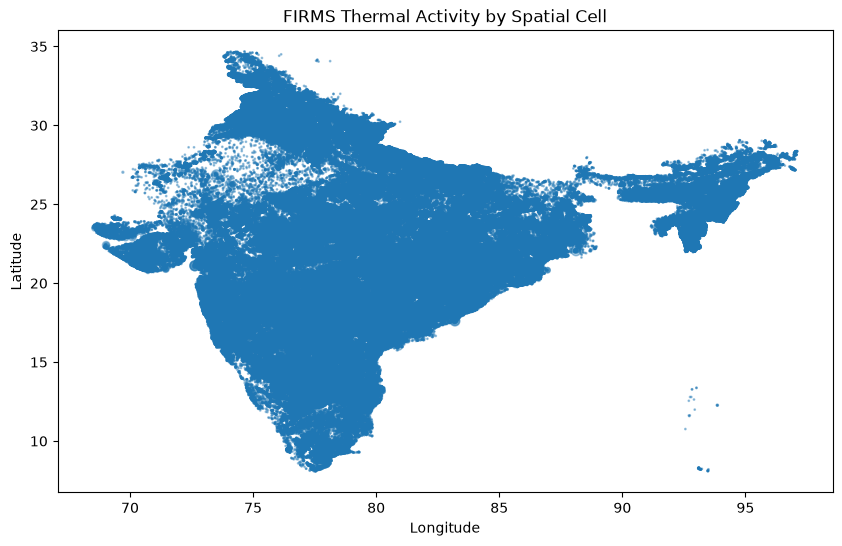

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    cell_stats["lon_grid"],
    cell_stats["lat_grid"],
    s=np.clip(cell_stats["observation_count"] / 10, 1, 50),
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("FIRMS Thermal Activity by Spatial Cell")
plt.show()

In [16]:
print("Unique TYPE values:")
print(df["type"].unique())

print("\nTYPE distribution:")
print(df["type"].value_counts(dropna=False))

Unique TYPE values:
[0 2 3 1]

TYPE distribution:
type
0    1523739
2     212854
3       2926
1         31
Name: count, dtype: int64


In [18]:
print("Unique confidence values:")
print(df["confidence"].unique())

print("\nUnique satellite values:")
print(df["satellite"].unique())

print("\nUnique instrument values:")
print(df["instrument"].unique())

Unique confidence values:
<StringArray>
['n', 'h', 'l']
Length: 3, dtype: str

Unique satellite values:
<StringArray>
['SNPP']
Length: 1, dtype: str

Unique instrument values:
<StringArray>
['SNPP']
Length: 1, dtype: str


In [19]:
print(df.dtypes)

display(df.head(10))

latitude               float64
longitude              float64
brightness             float64
scan                   float64
track                  float64
acq_date                   str
acq_time                 int64
satellite                  str
instrument                 str
confidence                 str
version                  int64
bright_t31             float64
frp                    float64
daynight                   str
type                     int64
acq_datetime    datetime64[us]
hour                     int32
day_of_week              int32
month                    int32
day_of_year              int32
lat_grid               float64
lon_grid               float64
grid_id                    str
dtype: object


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,daynight,type,acq_datetime,hour,day_of_week,month,day_of_year,lat_grid,lon_grid,grid_id
0,11.60804,79.38103,330.42,0.34,0.56,2023-09-15,726,SNPP,SNPP,n,...,D,0,2023-09-15 07:26:00,7,4,9,258,11.60,79.38,11.6_79.38
1,9.83476,79.06087,367.00,0.38,0.59,2023-09-15,726,SNPP,SNPP,h,...,D,0,2023-09-15 07:26:00,7,4,9,258,9.83,79.06,9.83_79.06
2,9.65347,78.72186,338.66,0.40,0.60,2023-09-15,726,SNPP,SNPP,n,...,D,0,2023-09-15 07:26:00,7,4,9,258,9.65,78.72,9.65_78.72
3,9.83540,79.06435,345.56,0.38,0.59,2023-09-15,726,SNPP,SNPP,n,...,D,0,2023-09-15 07:26:00,7,4,9,258,9.83,79.06,9.83_79.06
4,12.68536,79.35842,343.66,0.32,0.55,2023-09-15,726,SNPP,SNPP,n,...,D,0,2023-09-15 07:26:00,7,4,9,258,12.68,79.35,12.68_79.35
5,15.73259,80.06173,330.60,0.51,0.50,2023-09-15,727,SNPP,SNPP,n,...,D,0,2023-09-15 07:27:00,7,4,9,258,15.73,80.06,15.73_80.06
6,14.18213,79.91819,334.23,0.56,0.51,2023-09-15,727,SNPP,SNPP,n,...,D,0,2023-09-15 07:27:00,7,4,9,258,14.18,79.91,14.18_79.91
7,14.17433,79.98632,331.75,0.55,0.51,2023-09-15,727,SNPP,SNPP,n,...,D,0,2023-09-15 07:27:00,7,4,9,258,14.17,79.98,14.17_79.98
8,20.96601,85.17817,331.79,0.39,0.36,2023-09-15,728,SNPP,SNPP,n,...,D,2,2023-09-15 07:28:00,7,4,9,258,20.96,85.17,20.96_85.17
9,20.96211,85.17504,330.19,0.39,0.36,2023-09-15,728,SNPP,SNPP,n,...,D,2,2023-09-15 07:28:00,7,4,9,258,20.96,85.17,20.96_85.17


In [20]:
OUTPUT_PATH = "../data/processed/firms_spatial_features.csv"

cell_stats.to_csv(OUTPUT_PATH, index=False)

print(f"Saved {len(cell_stats):,} spatial cells")
print(f"File: {OUTPUT_PATH}")

Saved 644,699 spatial cells
File: ../data/processed/firms_spatial_features.csv


## Label Strategy

FIRMS observations do not automatically provide ground-truth labels for
industrial fires or persistent thermal sources.

Therefore, FIRMS `type` will not be assumed to be the prediction target.

Potential approaches:
1. External verified labels
2. Carefully designed weak supervision using independent evidence
3. Unsupervised/anomaly detection if reliable labels are unavailable

The final approach will be selected after data validation.

In [21]:
# Check whether FIRMS type is useful as a feature,
# but do not assign it as our target.

print("TYPE values:")
print(df["type"].value_counts(dropna=False))

print("\nNumber of unique TYPE values:")
print(df["type"].nunique())

TYPE values:
type
0    1523739
2     212854
3       2926
1         31
Name: count, dtype: int64

Number of unique TYPE values:
4


In [22]:
candidate_features = [
    "observation_count",
    "mean_frp",
    "max_frp",
    "mean_brightness",
    "max_brightness",
    "persistence_days",
    "active_days",
    "recurrence_ratio",
    "day_observations",
    "night_observations",
    "night_ratio"
]

X_current = cell_stats[candidate_features].copy()

print("Feature matrix shape:", X_current.shape)
display(X_current.head())

Feature matrix shape: (644699, 11)


,observation_count,mean_frp,max_frp,mean_brightness,max_brightness,persistence_days,active_days,recurrence_ratio,day_observations,night_observations,night_ratio
0,3,3.740,6.57,336.660,344.37,703.016667,3,0.004267,3,0,0.0
1,1,3.260,3.26,334.940,334.94,0.000000,1,1.000000,1,0,0.0
2,1,0.560,0.56,300.150,300.15,0.000000,1,1.000000,0,1,1.0
3,2,4.295,5.68,336.225,341.91,0.000000,1,1.000000,2,0,0.0
4,1,1.480,1.48,305.720,305.72,0.000000,1,1.000000,0,1,1.0


In [23]:
print("Missing values:")
display(X_current.isna().sum())

print("\nInfinite values:")
print(np.isinf(X_current.select_dtypes(include=np.number)).sum())

Missing values:


observation_count     0
mean_frp              0
max_frp               0
mean_brightness       0
max_brightness        0
persistence_days      0
active_days           0
recurrence_ratio      0
day_observations      0
night_observations    0
night_ratio           0
dtype: int64


Infinite values:
observation_count     0
mean_frp              0
max_frp               0
mean_brightness       0
max_brightness        0
persistence_days      0
active_days           0
recurrence_ratio      0
day_observations      0
night_observations    0
night_ratio           0
dtype: int64


In [24]:
try:
    import osmnx as ox
    print("OSMnx version:", ox.__version__)
except ImportError:
    print("OSMnx is not installed.")

OSMnx is not installed.


In [25]:
persistent_sample = (
    cell_stats[
        (cell_stats["active_days"] >= 5) &
        (cell_stats["observation_count"] >= 10)
    ]
    .sort_values(
        ["active_days", "observation_count"],
        ascending=False
    )
    .head(20)
    .copy()
)

display(
    persistent_sample[
        [
            "grid_id",
            "lat_grid",
            "lon_grid",
            "observation_count",
            "active_days",
            "persistence_days"
        ]
    ]
)

,grid_id,lat_grid,lon_grid,observation_count,active_days,persistence_days
252598,21.1_72.64,21.10,72.64,3139,796,1012.490972
252597,21.1_72.63,21.10,72.63,2823,786,1012.490972
392752,23.68_86.39,23.68,86.39,2785,722,1018.015278
300469,22.04_83.73,22.04,83.73,3217,717,1015.054167
398051,23.76_86.4,23.76,86.40,2630,707,1019.521528
234038,20.79_85.25,20.79,85.25,2441,691,1018.015278
241357,20.96_85.17,20.96,85.17,3060,687,1019.522917
397406,23.75_86.4,23.75,86.40,1594,680,1018.534722
362957,23.16_82.34,23.16,82.34,1656,677,1008.993750
398677,23.77_86.2,23.77,86.20,1946,652,1013.997917


In [26]:
print("Latitude range:",
      persistent_sample["lat_grid"].min(),
      "to",
      persistent_sample["lat_grid"].max())

print("Longitude range:",
      persistent_sample["lon_grid"].min(),
      "to",
      persistent_sample["lon_grid"].max())

Latitude range: 15.17 to 23.77
Longitude range: 72.63 to 88.12


In [ ]:
import pandas as pd

DATA_PATH = "../data/raw/FIRMS/fire_archive_SV-C2_806010.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

Shape: (1739550, 15)


In [29]:
candidate = persistent_sample.iloc[0]

lat = float(candidate["lat_grid"])
lon = float(candidate["lon_grid"])

print("Candidate grid:", candidate["grid_id"])
print("Latitude:", lat)
print("Longitude:", lon)

Candidate grid: 21.1_72.64
Latitude: 21.1
Longitude: 72.64


In [31]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
e:\SIH26162\.venv-1\Scripts\python.exe

Python version:
3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [32]:
import site

print("\nPackage locations:")
print(site.getsitepackages())


Package locations:
['e:\\SIH26162\\.venv-1', 'e:\\SIH26162\\.venv-1\\Lib\\site-packages']


In [33]:
import sys
!{sys.executable} -m pip install osmnx

  Using cached osmnx-2.1.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached osmnx-2.1.1-py3-none-any.whl (104 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)

   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import osmnx as ox

print("OSMnx version:", ox.__version__)

OSMnx version: 2.1.1


In [36]:
candidate = persistent_sample.iloc[0]

lat = float(candidate["lat_grid"])
lon = float(candidate["lon_grid"])

print("Grid:", candidate["grid_id"])
print("Latitude:", lat)
print("Longitude:", lon)

Grid: 21.1_72.64
Latitude: 21.1
Longitude: 72.64


In [37]:
import osmnx as ox

tags = {
    "landuse": "industrial",
    "industrial": True,
    "power": True,
    "man_made": ["works", "storage_tank"]
}

osm_features = ox.features_from_point(
    (lat, lon),
    tags=tags,
    dist=2000
)

print("OSM features found:", len(osm_features))
display(osm_features.reset_index().head(20))

OSM features found: 82


,element,id,geometry,power,addr:city,landuse,man_made,name,operator,website,...,substation,circuits,frequency,plant:method,plant:output:electricity,plant:source,plant:type,source,wikidata,building
0,node,1724318620,POINT (72.65854 21.10952),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,1724318633,POINT (72.65787 21.10959),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,1724318634,POINT (72.65708 21.10966),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,1724318635,POINT (72.65611 21.10976),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,1724318664,POINT (72.65849 21.11058),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,node,1724318668,POINT (72.65283 21.11069),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,node,1724318670,POINT (72.65253 21.11072),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,node,1724318687,POINT (72.65244 21.11161),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,node,1724318690,POINT (72.65339 21.11224),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,node,1724318695,POINT (72.65313 21.11281),tower,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
osm_raw = osm_features.reset_index()

print("Columns returned by OSM:")
print(osm_raw.columns.tolist())

for col in ["landuse", "industrial", "power", "man_made"]:
    if col in osm_raw.columns:
        print(f"\n{col}:")
        print(osm_raw[col].value_counts(dropna=False).head(10))

Columns returned by OSM:
['element', 'id', 'geometry', 'power', 'addr:city', 'landuse', 'man_made', 'name', 'operator', 'website', 'industrial', 'voltage', 'cables', 'substation', 'circuits', 'frequency', 'plant:method', 'plant:output:electricity', 'plant:source', 'plant:type', 'source', 'wikidata', 'building']

landuse:
landuse
NaN           77
industrial     5
Name: count, dtype: int64

industrial:
industrial
NaN    81
oil     1
Name: count, dtype: int64

power:
power
tower         41
NaN           23
line          11
substation     5
plant          2
Name: count, dtype: int64

man_made:
man_made
NaN             61
storage_tank    20
works            1
Name: count, dtype: int64


In [39]:
import osmnx as ox
import pandas as pd
import numpy as np
import time

def get_osm_context(lat, lon, radius=2000):
    """
    Get OSM contextual features around one FIRMS spatial cell.
    """

    tags = {
        "landuse": "industrial",
        "industrial": True,
        "power": True,
        "man_made": ["works", "storage_tank"]
    }

    try:
        gdf = ox.features_from_point(
            (lat, lon),
            tags=tags,
            dist=radius
        )

        result = {
            "osm_feature_count": len(gdf),
            "osm_industrial_count": 0,
            "osm_power_count": 0,
            "osm_manmade_count": 0
        }

        if "landuse" in gdf.columns:
            result["osm_industrial_count"] += (
                gdf["landuse"] == "industrial"
            ).sum()

        if "industrial" in gdf.columns:
            result["osm_industrial_count"] += (
                gdf["industrial"].notna()
            ).sum()

        if "power" in gdf.columns:
            result["osm_power_count"] = (
                gdf["power"].notna()
            ).sum()

        if "man_made" in gdf.columns:
            result["osm_manmade_count"] = (
                gdf["man_made"].isin(
                    ["works", "storage_tank"]
                )
            ).sum()

        return result

    except Exception as e:
        print(f"OSM error at {lat}, {lon}: {e}")

        return {
            "osm_feature_count": np.nan,
            "osm_industrial_count": np.nan,
            "osm_power_count": np.nan,
            "osm_manmade_count": np.nan
        }

In [ ]:
import pandas as pd

DATA_PATH = "../data/raw/FIRMS/fire_archive_SV-C2_806010.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

Shape: (1739550, 15)


In [41]:
test_candidates = persistent_sample.head(5).copy()

osm_results = []

for _, row in test_candidates.iterrows():

    result = get_osm_context(
        row["lat_grid"],
        row["lon_grid"],
        radius=2000
    )

    result["grid_id"] = row["grid_id"]

    osm_results.append(result)

    time.sleep(1)

osm_test = pd.DataFrame(osm_results)

display(osm_test)

OSM error at 22.04, 83.73: No matching features. Check query location, tags, and log.
OSM error at 23.76, 86.4: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))


,osm_feature_count,osm_industrial_count,osm_power_count,osm_manmade_count,grid_id
0,82.0,6.0,59.0,21.0,21.1_72.64
1,44.0,4.0,22.0,20.0,21.1_72.63
2,37.0,0.0,37.0,0.0,23.68_86.39
3,NaN,NaN,NaN,NaN,22.04_83.73
4,NaN,NaN,NaN,NaN,23.76_86.4


In [ ]:
test_merged = test_candidates.merge(
    osm_test,
    on="grid_id",
    how="left"
)

display(
    test_merged[
        [
            "grid_id",
            "observation_count",
            "active_days",
            "persistence_days",
            "osm_feature_count",
            "osm_industrial_count",
            "osm_power_count",
            "osm_manmade_count"
        ]
    ]
)